# EDA for economics data for AlgebraKit

This notebook explores and analyses the syntetic data generated for problem of ASAG
**Important**: The data is syntetically generated because AlgebraKit did not provide us with data that can be used for ASAG focused on secondary school.

This EDA is on questions on economics. The reason we are analysing economics questions is that the AlgebraKit Fontys team and the clients agreed that economics is a good starting subject to focus on.

The study program used for generating the syntetic data is: 
https://www.examenblad.nl/system/files/2012/exprog/examenprogramma_economie_havo_vwo_2015.pdf

## 1. Generating syntetic data

For the generation of data, we used Gemini 2.5 Flash because of its big context window. We used this prompt:

```json
You are a Dutch textbook publisher. Generate a json of 100 items with questions and answers related to economics studied by Dutch kids, following the syllabus i will provide. The answers must have key points (at least 4 where it is possible) that are valid for the level of education and must be readable to kids of age 11-14. Generate your answer in json format, in English, following this structure:
[
  {
    "question_id": 1,
    "question_text": "Explain inflation",
    "key_points": [
      {"text": "General increase in prices", "weight": 1},
      {"text": "Reduction of purchasing power", "weight": 1}
    ]
  },
  {
    "question_id": 2,
    "question_text": "What are three adaptations that help desert animals survive?",
    "key_points": [
      {"text": "Store water in their bodies", "weight": 1},
      {"text": "Active at night", "weight": 1},
      {"text": "Light-colored skin", "weight": 1}
    ]
  }
]
This is the dutch syllabus for HAVO for economics. Use it to create the questions on topics that are studied in secondary school. 
Domain A Skills
The candidate can recognize and apply economic concepts in various contexts.
Domain B Concept of Scarcity
The candidate can analyze in contexts how limited resources and unlimited needs force choices to be made.
Domain C Concept of Exchange
The candidate can analyze in contexts how the exchange process forms the basis for optimal allocation of resources and optimal utilization of comparative advantages. Furthermore,
the candidate can analyze how exchange facilitates the division of labor and how money makes the exchange process smoother.
... (the full syllabus was provided to Gemini, for demonstration and layout purposes here it is shortened)
```

## 2. EDA

In [29]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from wordcloud import WordCloud
from nltk.corpus import stopwords


In [6]:
with open('../data/questions/economics.json', 'r', encoding='utf-8') as f:
    economics_data = json.load(f)

print(f"Total number of questions: {len(economics_data)}")
print(f"Data type: {type(economics_data)}")
print(f"First question structure: {list(economics_data[0].keys())}")


Total number of questions: 201
Data type: <class 'list'>
First question structure: ['question_id', 'question_text', 'key_points']


In [7]:
df = pd.DataFrame(economics_data)
df.head()


,question_id,question_text,key_points
0,1,Define the core economic problem of 'scarcity'.,"[{'text': 'We have unlimited wants and needs',..."
1,2,What is 'opportunity cost'?,[{'text': 'It is the value of the thing you ch...
2,3,Give an example of a resource that is scarce.,[{'text': 'Time: You only have 24 hours in a d...
3,4,Explain the difference between a need and a want.,[{'text': 'A 'need' is something you must have...
4,5,How does scarcity force the government to make...,[{'text': 'The money the government collects (...


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   question_id    201 non-null    int64 
 1   question_text  201 non-null    object
 2   key_points     201 non-null    object
dtypes: int64(1), object(2)
memory usage: 4.8+ KB


In [9]:
df['question_length'] = df['question_text'].str.len()
df['num_key_points'] = df['key_points'].apply(len)
df['total_weight'] = df['key_points'].apply(lambda x: sum(point['weight'] for point in x))

print("Basic statistics:")
print(f"Question length - Mean: {df['question_length'].mean():.2f}, Std: {df['question_length'].std():.2f}")
print(f"Number of key points - Mean: {df['num_key_points'].mean():.2f}, Std: {df['num_key_points'].std():.2f}")
print(f"Total weight - Mean: {df['total_weight'].mean():.2f}, Std: {df['total_weight'].std():.2f}")


Basic statistics:
Question length - Mean: 59.58, Std: 20.42
Number of key points - Mean: 3.99, Std: 0.14
Total weight - Mean: 3.99, Std: 0.14


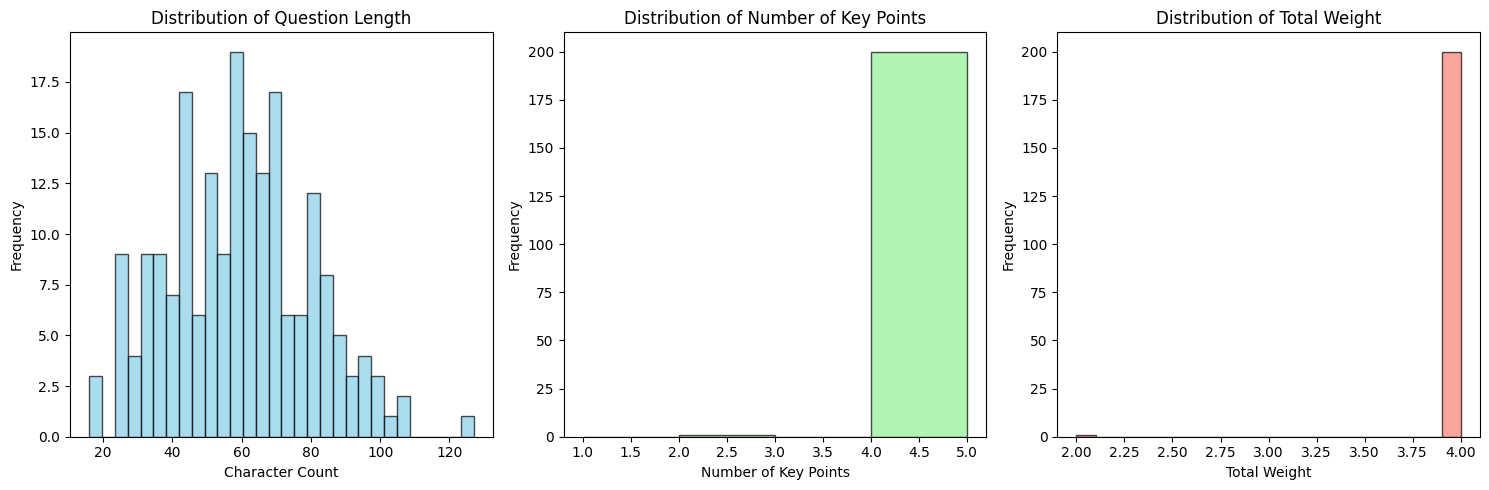

In [10]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df['question_length'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Question Length')
plt.xlabel('Character Count')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(df['num_key_points'], bins=range(1, df['num_key_points'].max()+2), alpha=0.7, color='lightgreen', edgecolor='black')
plt.title('Distribution of Number of Key Points')
plt.xlabel('Number of Key Points')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(df['total_weight'], bins=20, alpha=0.7, color='salmon', edgecolor='black')
plt.title('Distribution of Total Weight')
plt.xlabel('Total Weight')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [11]:
print("Key Points Analysis:")
print(f"Minimum key points per question: {df['num_key_points'].min()}")
print(f"Maximum key points per question: {df['num_key_points'].max()}")
print(f"Most common number of key points: {df['num_key_points'].mode().iloc[0]}")

print("\nWeight Analysis:")
print(f"Minimum total weight: {df['total_weight'].min()}")
print(f"Maximum total weight: {df['total_weight'].max()}")
print(f"All weights are equal to 1: {all(df['total_weight'] == df['num_key_points'])}")


Key Points Analysis:
Minimum key points per question: 2
Maximum key points per question: 4
Most common number of key points: 4

Weight Analysis:
Minimum total weight: 2
Maximum total weight: 4
All weights are equal to 1: True


In [12]:
all_key_points = []
for key_points_list in df['key_points']:
    for point in key_points_list:
        all_key_points.append(point['text'])

print(f"Total number of individual key points: {len(all_key_points)}")
print(f"Average key point length: {np.mean([len(point) for point in all_key_points]):.2f} characters")


Total number of individual key points: 802
Average key point length: 82.02 characters


In [34]:
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
try:
    stop_words = set(stopwords.words('english'))
except:
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))

question_words = []
for question in df['question_text']:
    words = re.findall(r'\b\w+\b', question.lower())
    # Filter out stopwords and short words
    filtered_words = [word for word in words if word not in stop_words and len(word) > 2]
    question_words.extend(filtered_words)

word_freq = Counter(question_words)
print("Most common meaningful words in questions (stopwords removed):")
print(word_freq.most_common(20))


Most common meaningful words in questions (stopwords removed):
[('explain', 34), ('market', 32), ('concept', 22), ('price', 19), ('domain', 17), ('government', 16), ('affect', 15), ('exchange', 14), ('example', 13), ('give', 12), ('money', 12), ('economic', 11), ('difference', 9), ('role', 9), ('good', 9), ('define', 8), ('main', 8), ('demand', 8), ('business', 8), ('trade', 8)]


In [35]:
key_point_words = []
for key_point in all_key_points:
    words = re.findall(r'\b\w+\b', key_point.lower())
    # Filter out stopwords and short words
    filtered_words = [word for word in words if word not in stop_words and len(word) > 2]
    key_point_words.extend(filtered_words)

key_point_word_freq = Counter(key_point_words)
print("Most common meaningful words in key points (stopwords removed):")
print(key_point_word_freq.most_common(20))


Most common meaningful words in key points (stopwords removed):
[('price', 127), ('money', 103), ('people', 71), ('goods', 63), ('like', 56), ('market', 56), ('government', 53), ('good', 51), ('interest', 46), ('cost', 42), ('total', 41), ('income', 40), ('country', 38), ('time', 36), ('new', 36), ('means', 35), ('less', 35), ('prices', 33), ('buy', 32), ('one', 32)]


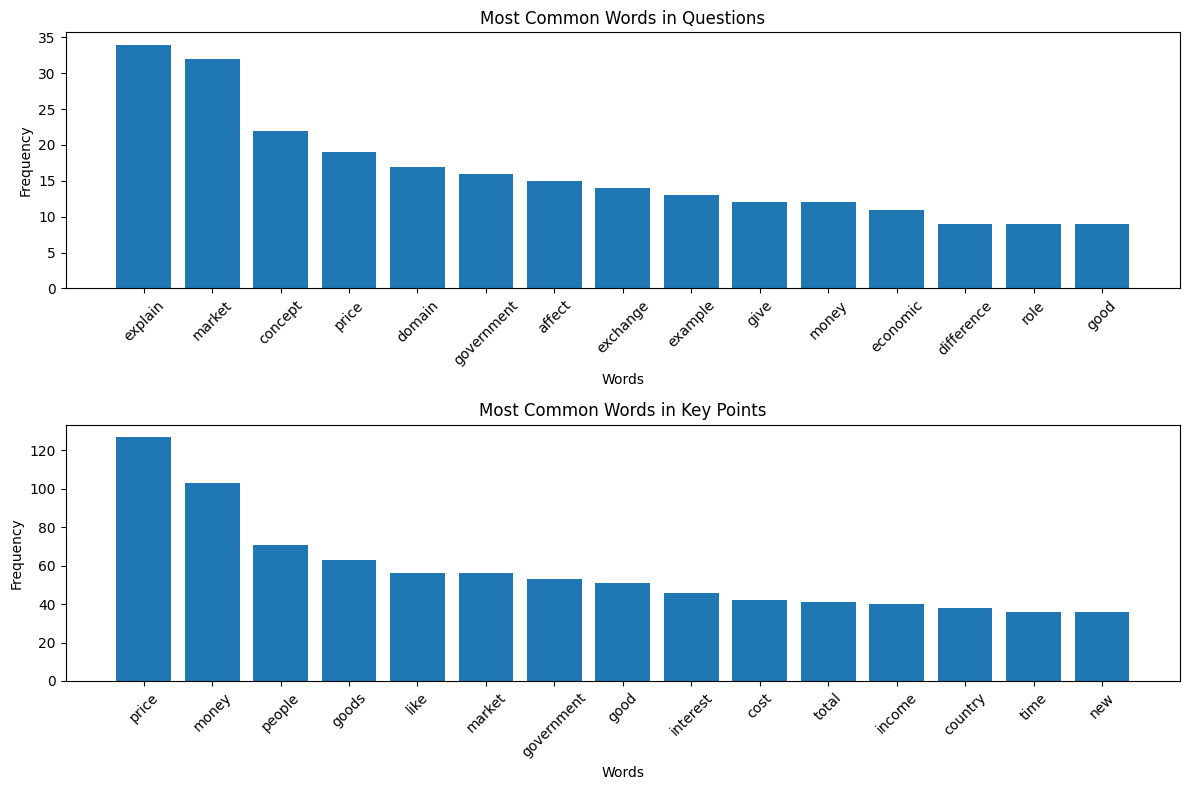

In [36]:
plt.figure(figsize=(12, 8))

top_words = dict(word_freq.most_common(15))
plt.subplot(2, 1, 1)
plt.bar(range(len(top_words)), list(top_words.values()))
plt.title('Most Common Words in Questions')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(range(len(top_words)), list(top_words.keys()), rotation=45)

top_key_words = dict(key_point_word_freq.most_common(15))
plt.subplot(2, 1, 2)
plt.bar(range(len(top_key_words)), list(top_key_words.values()))
plt.title('Most Common Words in Key Points')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(range(len(top_key_words)), list(top_key_words.keys()), rotation=45)

plt.tight_layout()
plt.show()


In [37]:
question_types = []
for question in df['question_text']:
    if question.strip().endswith('?'):
        if question.strip().startswith(('What', 'How', 'Why', 'When', 'Where', 'Which', 'Who')):
            question_types.append('Wh-question')
        elif question.strip().startswith(('Can', 'Could', 'Would', 'Should', 'Will', 'Do', 'Does', 'Did', 'Is', 'Are', 'Was', 'Were')):
            question_types.append('Yes/No question')
        else:
            question_types.append('Other question')
    else:
        question_types.append('Statement/Command')

question_type_counts = Counter(question_types)
print("Question types distribution:")
for qtype, count in question_type_counts.items():
    print(f"{qtype}: {count} ({count/len(df)*100:.1f}%)")


Question types distribution:
Statement/Command: 56 (27.9%)
Wh-question: 137 (68.2%)
Other question: 8 (4.0%)


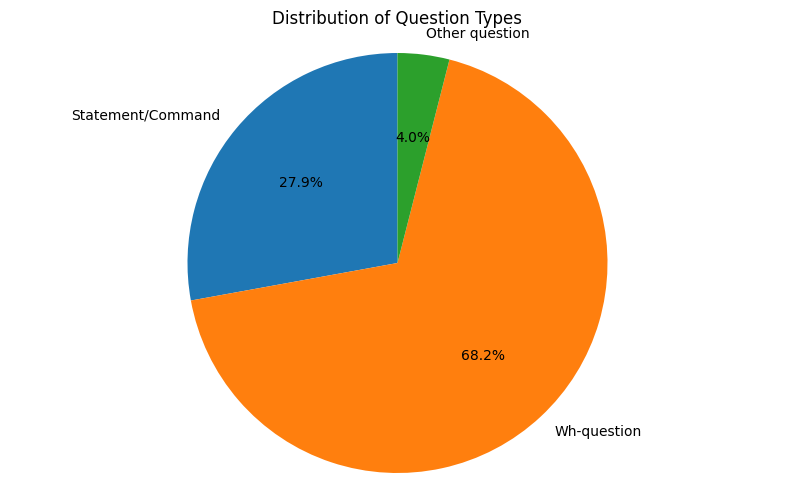

In [38]:
plt.figure(figsize=(10, 6))
plt.pie(question_type_counts.values(), labels=question_type_counts.keys(), autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Question Types')
plt.axis('equal')
plt.show()


In [41]:
print("Sample questions by type:")
for qtype in df['question_type'].unique():
    print(f"\n{qtype}:")
    sample_questions = df[df['question_type'] == qtype]['question_text'].head(3).tolist()
    for i, q in enumerate(sample_questions, 1):
        print(f"  {i}. {q}")


Sample questions by type:

Statement/Command:
  1. Define the core economic problem of 'scarcity'.
  2. Give an example of a resource that is scarce.
  3. Explain the difference between a need and a want.

Wh-question:
  1. What is 'opportunity cost'?
  2. How does scarcity force the government to make choices?
  3. What is the primary function of exchange in an economy?

Other question:
  1. If a small price increase on a necessary medicine causes very few people to stop buying it, is the demand elastic or inelastic?
  2. If a firm operates in a perfectly competitive market, what is its relationship with the market price?
  3. In the context of the business cycle, what is a 'recession'?


In [42]:
longest_questions = df.nlargest(5, 'question_length')[['question_text', 'question_length', 'num_key_points']]
print("Longest questions:")
for idx, row in longest_questions.iterrows():
    print(f"\nLength: {row['question_length']}, Key Points: {row['num_key_points']}")
    print(f"Question: {row['question_text']}")


Longest questions:

Length: 127, Key Points: 4
Question: If a small price increase on a necessary medicine causes very few people to stop buying it, is the demand elastic or inelastic?

Length: 106, Key Points: 4
Question: Give an example of a situation where negotiation is a better choice than individual action for a consumer.

Length: 106, Key Points: 4
Question: How can a government policy that changes the price of one good affect the market for a complementary good?

Length: 102, Key Points: 4
Question: How does the price mechanism help solve the basic economic question 'For whom to produce?' (Domain D).

Length: 101, Key Points: 4
Question: If a firm operates in a perfectly competitive market, what is its relationship with the market price?


In [43]:
shortest_questions = df.nsmallest(5, 'question_length')[['question_text', 'question_length', 'num_key_points']]
print("Shortest questions:")
for idx, row in shortest_questions.iterrows():
    print(f"\nLength: {row['question_length']}, Key Points: {row['num_key_points']}")
    print(f"Question: {row['question_text']}")


Shortest questions:

Length: 16, Key Points: 4
Question: Define 'demand'.

Length: 16, Key Points: 4
Question: Define 'supply'.

Length: 17, Key Points: 2
Question: Explain inflation

Length: 24, Key Points: 4
Question: State the Law of Demand.

Length: 24, Key Points: 4
Question: State the Law of Supply.


In [44]:
questions_with_most_key_points = df.nlargest(5, 'num_key_points')[['question_text', 'question_length', 'num_key_points']]
print("Questions with most key points:")
for idx, row in questions_with_most_key_points.iterrows():
    print(f"\nKey Points: {row['num_key_points']}, Length: {row['question_length']}")
    print(f"Question: {row['question_text']}")


Questions with most key points:

Key Points: 4, Length: 47
Question: Define the core economic problem of 'scarcity'.

Key Points: 4, Length: 27
Question: What is 'opportunity cost'?

Key Points: 4, Length: 45
Question: Give an example of a resource that is scarce.

Key Points: 4, Length: 49
Question: Explain the difference between a need and a want.

Key Points: 4, Length: 55
Question: How does scarcity force the government to make choices?


## 3. Summary

In [45]:
print("Summary Statistics:")
print(f"Dataset contains {len(df)} economics questions")
print(f"Total key points across all questions: {len(all_key_points)}")
print(f"Average question length: {df['question_length'].mean():.1f} characters")
print(f"Average key points per question: {df['num_key_points'].mean():.1f}")
print(f"Question length range: {df['question_length'].min()} - {df['question_length'].max()} characters")
print(f"Key points range: {df['num_key_points'].min()} - {df['num_key_points'].max()} per question")
print(f"All key points have equal weight (weight = 1)")
print(f"Most common question type: {question_type_counts.most_common(1)[0][0]} ({question_type_counts.most_common(1)[0][1]} questions)")


Summary Statistics:
Dataset contains 201 economics questions
Total key points across all questions: 802
Average question length: 59.6 characters
Average key points per question: 4.0
Question length range: 16 - 127 characters
Key points range: 2 - 4 per question
All key points have equal weight (weight = 1)
Most common question type: Wh-question (137 questions)
